In [1]:
import numpy as np
import pandas as pd

from sklearn.linear_model import Perceptron
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    PrecisionRecallDisplay,
    recall_score,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


from src.config import DADOS_LIMPOS
from src.models import RANDOM_STATE

In [2]:
df = pd.read_parquet(DADOS_LIMPOS)
df.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,...,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
0,1001.0,153.40,2019.0,0.27760,0.04904,0.6656,0.14710,0.01587,0.2654,0.3001,...,25.38,0.11840,0.006399,0.1622,0.2419,0.03003,0.4601,10.38,0.9053,17.33
1,1326.0,74.08,1956.0,0.07864,0.01308,0.1866,0.07017,0.01340,0.1860,0.0869,...,24.99,0.08474,0.005225,0.1238,0.1812,0.01389,0.2750,17.77,0.7339,23.41
2,1203.0,94.03,1709.0,0.15990,0.04006,0.4245,0.12790,0.02058,0.2430,0.1974,...,23.57,0.10960,0.006150,0.1444,0.2069,0.02250,0.3613,21.25,0.7869,25.53
3,386.1,27.23,567.7,0.28390,0.07458,0.8663,0.10520,0.01867,0.2575,0.2414,...,14.91,0.14250,0.009110,0.2098,0.2597,0.05963,0.6638,20.38,1.1560,26.50
4,1297.0,94.44,1575.0,0.13280,0.02461,0.2050,0.10430,0.01885,0.1625,0.1980,...,22.54,0.10030,0.011490,0.1374,0.1809,0.01756,0.2364,14.34,0.7813,16.67


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   area_mean                569 non-null    float64
 1   area_se                  569 non-null    float64
 2   area_worst               569 non-null    float64
 3   compactness_mean         569 non-null    float64
 4   compactness_se           569 non-null    float64
 5   compactness_worst        569 non-null    float64
 6   concave points_mean      569 non-null    float64
 7   concave points_se        569 non-null    float64
 8   concave points_worst     569 non-null    float64
 9   concavity_mean           569 non-null    float64
 10  concavity_se             569 non-null    float64
 11  concavity_worst          569 non-null    float64
 12  diagnosis                569 non-null    str    
 13  fractal_dimension_mean   569 non-null    float64
 14  fractal_dimension_se     569 non-null

In [4]:
X= df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [5]:
y.value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [6]:
le = LabelEncoder()
y = le.fit_transform(y)


In [7]:
bincounts = np.bincount(y)
print(bincounts)

[357 212]


Classes:
- 1: Maligno
- 0: Benigno

In [8]:
y[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [9]:
bincounts/len(y)

array([0.62741652, 0.37258348])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

In [11]:
np.bincount(y_train)/len(y_train)

array([0.62676056, 0.37323944])

In [12]:
np.bincount(y_test)/len(y_test)

array([0.62937063, 0.37062937])

In [13]:
clf = Perceptron()
clf.fit(X_train, y_train)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


In [14]:
y_pred = clf.predict(X_test)

### Métricas do Modelo de Classificação

In [15]:
clf.score(X_test, y_test)

0.9020979020979021

In [16]:
confusion_matrix(y_test, y_pred)

array([[89,  1],
       [13, 40]])

In [17]:
confusion_matrix(y_test, y_pred, normalize="all")*100

array([[62.23776224,  0.6993007 ],
       [ 9.09090909, 27.97202797]])

In [18]:
confusion_matrix(y_test, y_pred, normalize="true")*100

array([[98.88888889,  1.11111111],
       [24.52830189, 75.47169811]])

In [19]:
confusion_matrix(y_test, y_pred, normalize="pred")*100

array([[87.25490196,  2.43902439],
       [12.74509804, 97.56097561]])

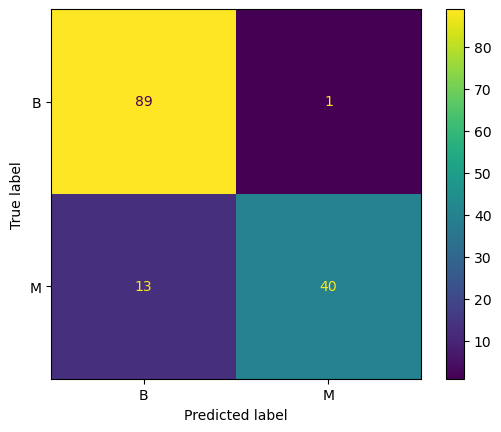

In [20]:
#matriz de confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot();

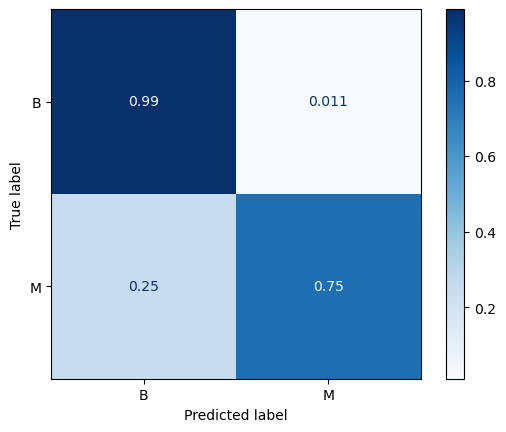

In [21]:
#matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_, normalize="true", cmap="Blues");

In [22]:
#Recall score
recall_score(y_test, y_pred)

0.7547169811320755

In [23]:
#Precision score
precision_score(y_test, y_pred)

0.975609756097561

In [24]:
#F1 Score
f1_score(y_test, y_pred)

0.851063829787234

In [29]:
#F beta Score
fbeta_score(y_test, y_pred, beta=0.5)

0.9216589861751152

In [28]:
#F beta Score
fbeta_score(y_test, y_pred, beta=2)

0.7905138339920948

#### Curva ROC

In [30]:
#Curva ROC

roc_auc = roc_auc_score(y_test, y_pred)
roc_auc

0.8718029350104822

In [31]:
roc_curve(y_test, y_pred)

(array([0.        , 0.01111111, 1.        ]),
 array([0.        , 0.75471698, 1.        ]),
 array([inf,  1.,  0.]))

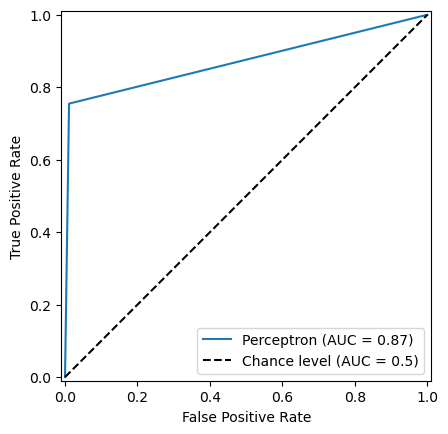

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name="Perceptron")
disp.plot(plot_chance_level = True)

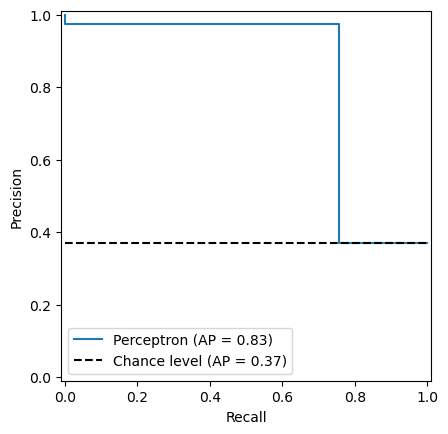

In [41]:
#Curva de Precisão-Recall

precision, recall, thresholds = precision_recall_curve(y_test, y_pred)
disp = PrecisionRecallDisplay(
    precision=precision, 
    recall=recall, 
    average_precision=average_precision_score(y_test, y_pred), 
    name="Perceptron",
    prevalence_pos_label = y_test.mean()
    )
disp.plot(plot_chance_level=True);

In [42]:
#Classification report
print(classification_report(y_test, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

           B       0.87      0.99      0.93        90
           M       0.98      0.75      0.85        53

    accuracy                           0.90       143
   macro avg       0.92      0.87      0.89       143
weighted avg       0.91      0.90      0.90       143



- O modelo está funcionando muito bem para a classe `B`, com alta precisão, recall e F1.
- Mas para a classe `M`, o recall está bem alto (0.98), mas o restante, recall e f1-score, estão muito baixo.